``` 
hypothesis 
-Given the current state of the table and past season, what is the realistic probablitiy that each team could still win?
1.who is most likely to win the premier league based on historical data and current season data
2.who are most likely finish in top 4 to play in champions league next year
3.who are most likely finish at 5 and 6 place
4.who are most likely be relagated at the end of season or place(18,19$20)
```

In [3]:
import pandas as pd
# YOU MUST LOAD THE FILE FIRST!
df_complete = pd.read_csv('data/premier_league_complete_2016_2026.csv')
# NOW you can use df_complete
print(df_complete.shape)
df_complete.head(20)


(200, 12)


,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Season
0,1,Chelsea,38,30,3,5,85,33,52,93,2.45,2016-17
1,2,Tottenham,38,26,8,4,86,26,60,86,2.26,2016-17
2,3,Man City,38,23,9,6,80,39,41,78,2.05,2016-17
3,4,Liverpool,38,22,10,6,78,42,36,76,2.00,2016-17
4,5,Arsenal,38,23,6,9,77,44,33,75,1.97,2016-17
5,6,Man United,38,18,15,5,54,29,25,69,1.82,2016-17
6,7,Everton,38,17,10,11,62,44,18,61,1.61,2016-17
7,8,Southampton,38,12,10,16,41,48,-7,46,1.21,2016-17
8,9,Bournemouth,38,12,9,17,55,67,-12,46,1.21,2016-17
9,10,West Brom,38,12,9,17,43,51,-8,45,1.18,2016-17


```
from the data we can understand we have total 200 rows with 12 columns
```

In [4]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

```
1️⃣ pd.set_option('display.max_columns', None)(use of this code)

Purpose: Tells pandas “show all columns when printing a DataFrame”

Default behavior: If your table has many columns, pandas hides some of them and shows ... instead.

2️⃣ pd.set_option('display.width', 200)

Purpose: Sets the maximum width of the table when printed in the console

Default behavior: Pandas will wrap lines if the table is too wide for your screen.
```

In [5]:
df_complete.head(10)

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Season
0,1,Chelsea,38,30,3,5,85,33,52,93,2.45,2016-17
1,2,Tottenham,38,26,8,4,86,26,60,86,2.26,2016-17
2,3,Man City,38,23,9,6,80,39,41,78,2.05,2016-17
3,4,Liverpool,38,22,10,6,78,42,36,76,2.00,2016-17
4,5,Arsenal,38,23,6,9,77,44,33,75,1.97,2016-17
5,6,Man United,38,18,15,5,54,29,25,69,1.82,2016-17
6,7,Everton,38,17,10,11,62,44,18,61,1.61,2016-17
7,8,Southampton,38,12,10,16,41,48,-7,46,1.21,2016-17
8,9,Bournemouth,38,12,9,17,55,67,-12,46,1.21,2016-17
9,10,West Brom,38,12,9,17,43,51,-8,45,1.18,2016-17


## Data exploration

In [6]:
# check the number of appearances for the past 10 years
# if the number is below 10 it means the club was relegated
df_complete['Squad'].value_counts()


Squad
Chelsea             10
Tottenham           10
Man City            10
Liverpool           10
Arsenal             10
Man United          10
Everton             10
West Ham            10
Crystal Palace      10
Newcastle            9
Brighton             9
Southampton          8
Bournemouth          8
Leicester City       8
Burnley              8
Wolves               8
Aston Villa          7
Fulham               6
Watford              5
Brentford            5
Leeds United         4
Nottm Forest         4
West Brom            3
Sheffield United     3
Stoke City           2
Swansea City         2
Sunderland           2
Huddersfield         2
Norwich City         2
Hull City            1
Middlesbrough        1
Cardiff City         1
Luton Town           1
Ipswich Town         1
Name: count, dtype: int64

In [7]:
# top 3 counting per team
df_complete['Squad'].groupby(df_complete['Rk']).value_counts().head(10)

Rk  Squad     
1   Man City      6
    Liverpool     2
    Chelsea       1
    Arsenal       1
2   Arsenal       3
    Liverpool     2
    Man City      2
    Man United    2
    Tottenham     1
3   Chelsea       2
Name: count, dtype: int64

```
df_complete['Squad']This selects one column: "Squad"
groupby() is a pandas function used to split data into groups based on some column
value_counts() is a Series method that counts how many times each value appear
```

In [8]:
# Filter for top 3 finishers
top3 = df_complete[df_complete['Rk'] <= 3]

# Count finishes by team and rank
rank_counts = top3.groupby(['Squad', 'Rk']).size().unstack(fill_value=0)
rank_counts.head()

Rk,1,2,3
Squad,,,
Arsenal,1,3,0
Aston Villa,0,0,1
Chelsea,1,0,2
Liverpool,2,2,2
Man City,6,2,2


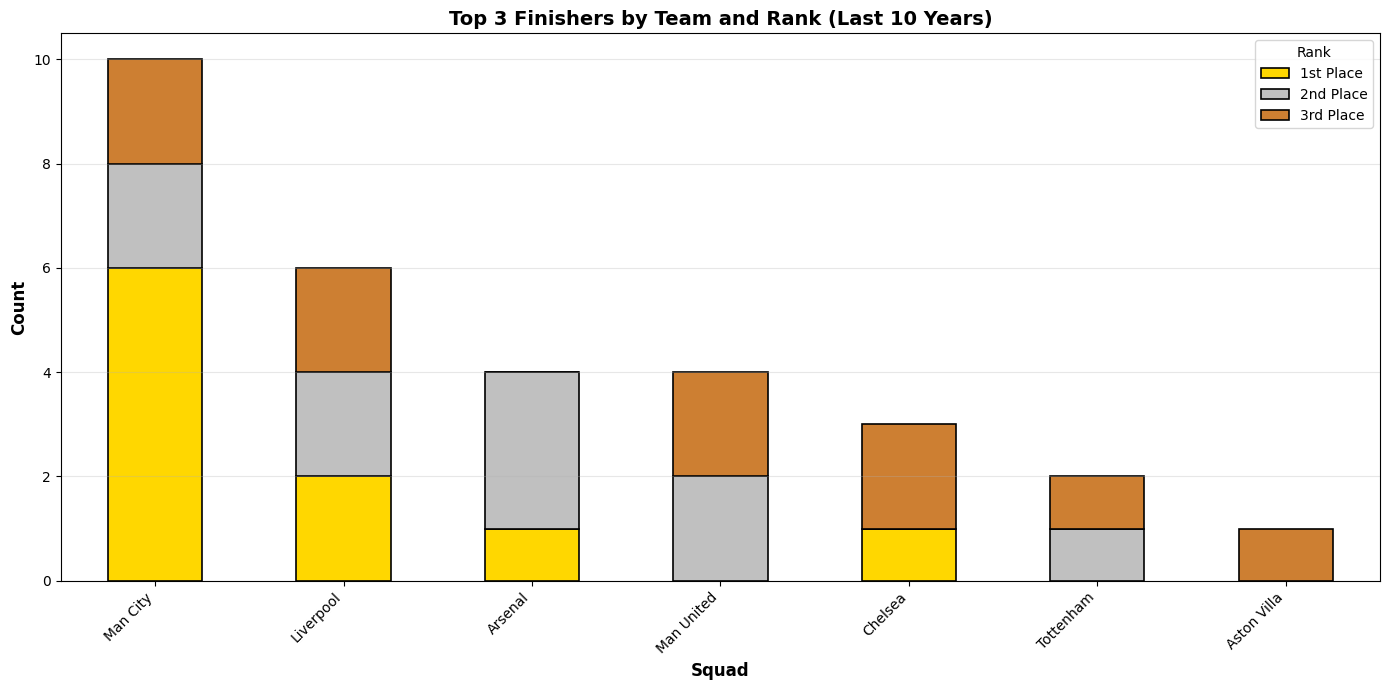


Detailed Breakdown:
Rk           1  2  3
Squad               
Man City     6  2  2
Liverpool    2  2  2
Arsenal      1  3  0
Man United   0  2  2
Chelsea      1  0  2
Tottenham    0  1  1
Aston Villa  0  0  1

Total Top 3 Finishes:
Squad
Man City       10
Liverpool       6
Arsenal         4
Man United      4
Chelsea         3
Tottenham       2
Aston Villa     1
dtype: int64


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter for top 3 finishers
top3 = df_complete[df_complete['Rk'] <= 3]

# Count finishes by team and rank
rank_counts = top3.groupby(['Squad', 'Rk']).size().unstack(fill_value=0)

# Sort by total appearances in top 3
rank_counts['Total'] = rank_counts.sum(axis=1)
rank_counts = rank_counts.sort_values('Total', ascending=False).drop('Total', axis=1)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 7))

# Define colors for each rank
colors = {
    1: '#FFD700',  # Gold for 1st place
    2: '#C0C0C0',  # Silver for 2nd place
    3: '#CD7F32'   # Bronze for 3rd place
}

# Plot stacked bars
rank_counts.plot(kind='bar', stacked=True, ax=ax, 
                 color=[colors.get(col, '#1f77b4') for col in rank_counts.columns],
                 edgecolor='black', linewidth=1.2)

# Customize
ax.set_xlabel('Squad', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Top 3 Finishers by Team and Rank (Last 10 Years)', fontsize=14, fontweight='bold')
ax.set_xticklabels(rank_counts.index, rotation=45, ha='right')
ax.legend(title='Rank', labels=['1st Place', '2nd Place', '3rd Place'], 
          loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show detailed breakdown
print("\nDetailed Breakdown:")
print(rank_counts)
print("\nTotal Top 3 Finishes:")
print(rank_counts.sum(axis=1).sort_values(ascending=False))


In [12]:
# i need also express this eda in more interactive way using plotly
import plotly.express as px
# this code is used to get the top 3 finishers only.
ranking_count=df_complete['Squad'].groupby(df_complete['Rk']).value_counts().reset_index(name='count')
# keep only top 3 finishers
ranking_count=ranking_count[ranking_count['Rk'].isin([1,2,3])]
# plot
fig = px.bar(ranking_count, x='Squad', y='count', color='Rk', barmode='stack',
                 title='top 3 finishers by team and rank(last 10 years)',
                 labels={'Squad':'Team', 'count': 'finish count', 'Rk': 'Rank'})
fig.update_layout(xaxis={'categoryorder': 'total descending'})
fig.show()

In [8]:
df_complete.describe()

,Rk,MP,W,D,L,GF,GA,GD,Pts,Pts/MP
count,200.000000,200.000000,200.00000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,10.500000,36.800000,14.26000,8.35500,14.185000,52.260000,52.125000,0.135000,51.105000,1.387950
std,5.780751,3.609034,6.43033,2.73613,6.052598,18.291399,14.513185,27.961509,18.717792,0.483721
min,1.000000,26.000000,1.00000,2.00000,1.000000,16.000000,18.000000,-69.000000,9.000000,0.350000
25%,5.750000,38.000000,10.00000,6.00000,10.000000,38.750000,42.000000,-19.000000,38.750000,1.050000
50%,10.500000,38.000000,13.00000,8.00000,15.000000,49.000000,52.000000,-3.000000,48.000000,1.300000
75%,15.250000,38.000000,18.00000,10.00000,19.000000,62.000000,62.000000,15.250000,63.000000,1.715000
max,20.000000,38.000000,32.00000,15.00000,29.000000,106.000000,104.000000,79.000000,100.000000,2.630000


In [9]:
# winning team for the past 10 years
# filter the winning team for the past ten years
winning_team = df_complete[df_complete["Rk"]==1][["Season","Squad","Pts","Pts/MP"]].sort_values("Season")

# display the results
print(winning_team)


      Season      Squad  Pts  Pts/MP
0    2016-17    Chelsea   93    2.45
20   2017-18   Man City  100    2.63
40   2018-19   Man City   98    2.58
60   2019-20  Liverpool   99    2.61
80   2020-21   Man City   86    2.26
100  2021-22   Man City   93    2.45
120  2022-23   Man City   89    2.34
140  2023-24   Man City   91    2.39
160  2024-25  Liverpool   84    2.21
180  2025-26    Arsenal   57    2.19


#### from the data i gain i can say the point 84 and above nearly guranetee to win the premierleague title

In [10]:
df_complete.head()

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Season
0,1,Chelsea,38,30,3,5,85,33,52,93,2.45,2016-17
1,2,Tottenham,38,26,8,4,86,26,60,86,2.26,2016-17
2,3,Man City,38,23,9,6,80,39,41,78,2.05,2016-17
3,4,Liverpool,38,22,10,6,78,42,36,76,2.00,2016-17
4,5,Arsenal,38,23,6,9,77,44,33,75,1.97,2016-17


In [11]:
# filter for the winning team for the past 9 year excluding the current season
winning_team_past_9year = df_complete[(df_complete["Rk"]==1) & (df_complete["Season"] != "2025-26")]

# compute the mean of pts/mp winning team for the past 9 years
ave_pts_mp_past_9 = winning_team_past_9year["Pts/MP"].mean()
# display the result
print(f"Average Pts/MP for the past 9 years winning team: {ave_pts_mp_past_9:.2f}")


Average Pts/MP for the past 9 years winning team: 2.44


In [12]:
df_complete.tail(20)

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Season
180,1,Arsenal,26,17,6,3,50,18,32,57,2.19,2025-26
181,2,Man City,26,16,5,5,54,24,30,53,2.04,2025-26
182,3,Aston Villa,26,15,5,6,37,27,10,50,1.92,2025-26
183,4,Man United,26,12,9,5,47,37,10,45,1.73,2025-26
184,5,Chelsea,26,12,8,6,47,30,17,44,1.69,2025-26
185,6,Liverpool,26,12,6,8,41,35,6,42,1.62,2025-26
186,7,Brentford,26,12,4,10,40,35,5,40,1.54,2025-26
187,8,Everton,26,10,7,9,29,30,-1,37,1.42,2025-26
188,9,Bournemouth,26,9,10,7,43,45,-2,37,1.42,2025-26
189,10,Newcastle,26,10,6,10,37,37,0,36,1.38,2025-26


In [13]:
# convert rk into binary 1 if the team won title otherwise make it 0
df_complete["is_champion"] = (df_complete["Rk"]==1).astype(int)

# filter only champion winning team only
champions_only = df_complete[df_complete["is_champion"]==1]

# display the result
print(champions_only[["Season", "Squad", "Pts", "Pts/MP", "is_champion"]])


      Season      Squad  Pts  Pts/MP  is_champion
0    2016-17    Chelsea   93    2.45            1
20   2017-18   Man City  100    2.63            1
40   2018-19   Man City   98    2.58            1
60   2019-20  Liverpool   99    2.61            1
80   2020-21   Man City   86    2.26            1
100  2021-22   Man City   93    2.45            1
120  2022-23   Man City   89    2.34            1
140  2023-24   Man City   91    2.39            1
160  2024-25  Liverpool   84    2.21            1
180  2025-26    Arsenal   57    2.19            1


In [14]:
df_complete.head()

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Season,is_champion
0,1,Chelsea,38,30,3,5,85,33,52,93,2.45,2016-17,1
1,2,Tottenham,38,26,8,4,86,26,60,86,2.26,2016-17,0
2,3,Man City,38,23,9,6,80,39,41,78,2.05,2016-17,0
3,4,Liverpool,38,22,10,6,78,42,36,76,2.00,2016-17,0
4,5,Arsenal,38,23,6,9,77,44,33,75,1.97,2016-17,0


In [15]:
# calculate the pts/mp only for champions
mean_pts_mp=champions_only["Pts/MP"].mean()
print(f"mean for pts/mp for chamions:{mean_pts_mp:.2f}")

mean for pts/mp for chamions:2.41


```
this value we get here different from the first one is because it exclude the current season anyhow it bit closer to the first one
```

## Ml modeling and prediction

In [16]:
from sklearn.ensemble import RandomForestClassifier ## for machine learning model
from sklearn.preprocessing import StandardScaler ## to normalize our feature
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, log_loss ## model evaluation
from sklearn.model_selection import cross_val_score # for cross validation
import numpy as np # for data manipulation 
import pandas as pd # for numerical analysis

In [17]:
# calculate how many games that each team left out of 38 games
df_complete["games_left"] = 38 - df_complete["MP"]

# estimate the final number of points if each team has keep their pace
# this one by itself can be a machine learning model
df_complete["projected_points"]=df_complete["Pts"]+df_complete["games_left"]*df_complete["Pts/MP"]
# create a binary column to show if the team was champion that season
df_complete["is_champion"]=(df_complete["Rk"]==1).astype(int)

In [18]:
df_complete.tail(3)

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Season,is_champion,games_left,projected_points
197,18,West Ham,26,6,6,14,32,49,-17,24,0.92,2025-26,0,12,35.04
198,19,Burnley,26,4,6,16,28,51,-23,18,0.69,2025-26,0,12,26.28
199,20,Wolves,26,1,6,19,16,48,-32,9,0.35,2025-26,0,12,13.20


In [19]:
# choose the fearure that used to train the model
features=["Pts/MP","GD","W","D","projected_points"]
# create a training dataset all season except the current season
df_train=df_complete[df_complete["Season"]!="2025-26"]
# create a test dataset for the current season
df_test=df_complete[df_complete["Season"]=="2025-26"]
# define feature matrix x and target variable y for training
x_train=df_train[features]
y_train=df_train["is_champion"]
x_test=df_test[features]

In [20]:
# set the model
model=RandomForestClassifier(n_estimators=180, random_state=42)
# fit the model
model.fit(x_train, y_train)
# this is the core steps that a model learn from the data and find patterns to predict the target variable based on the features provided

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",180
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
# predict a binary outcome for the training dataset
train_pred=model.predict(x_train)
# predict the probablity of being a champion
train_prob=model.predict_proba(x_train)[:,1]

In [22]:
# compute the accuracy of the model on the training dataset
accuracy=accuracy_score(y_train, train_pred)# so this compare the true labels(y_train) with the predictided value(train_pred)
print(f"training accuracy: {accuracy:.2f}")

training accuracy: 1.00


In [23]:
# the next step is compute roc_auc score to evaluate the mdel performance on the training dataset
roc_auc=roc_auc_score(y_train, train_prob)
print(f"training roc auc: {roc_auc:.2f}")
# so this code explain how well the model can distinguish between champion and non-champion teams based on the features provided.  

training roc auc: 1.00


``` 
why we use roc auc score because it looks at the probablity and describe how much the model is confident.while the acuracy tells the prediction part only it doesn't tell how much our model is confident
my ROC AUC = 1 → model perfectly separates champions from non-champions on training data

In [24]:
# now calculate the log loss for the training dataset
Logloss=log_loss(y_train, train_prob)
print(f"training log loss: {Logloss:.2f}")

training log loss: 0.02


```
the purpose of logloss is used to compare true labels with predicticed probablities then gives a score showing how much our prediction are wrong so it means lower logloss means higher confidence

In [25]:
# classification report
print("classification report:")
print(classification_report(y_train, train_pred))

classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       171
           1       1.00      1.00      1.00         9

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



```
This report summarizes:

Precision → How many predicted champions were actually champions

Recall → How many real champions were correctly predicted

F1-score → Balance between precision and recall

Support → How many samples of each class exist in the dataset

In [26]:
# show the confusion matrix
print("confusion matrix")
print(confusion_matrix(y_train, train_pred))#Compares true labels (y_train) with predicted labels (train_pred)

confusion matrix
[[171   0]
 [  0   9]]


In [27]:
# predict the probablity of being a champion for the test dataset
df_test["win_probablity"]=model.predict_proba(x_test)[:,1]# this part takes only the probablity of being champion.
# normalize the probablity so that all the teams add up to 100%
df_test["win_probablity(%)"]=df_test["win_probablity"]/df_test["win_probablity"].sum()*100
# round the probablity for better readiablity
df_test["win_probablity(%)"]=df_test["win_probablity(%)"].round(2)


In [28]:
df_test.head(20)

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Season,is_champion,games_left,projected_points,win_probablity,win_probablity(%)
180,1,Arsenal,26,17,6,3,50,18,32,57,2.19,2025-26,1,12,83.28,0.327778,100.0
181,2,Man City,26,16,5,5,54,24,30,53,2.04,2025-26,0,12,77.48,0.000000,0.0
182,3,Aston Villa,26,15,5,6,37,27,10,50,1.92,2025-26,0,12,73.04,0.000000,0.0
183,4,Man United,26,12,9,5,47,37,10,45,1.73,2025-26,0,12,65.76,0.000000,0.0
184,5,Chelsea,26,12,8,6,47,30,17,44,1.69,2025-26,0,12,64.28,0.000000,0.0
185,6,Liverpool,26,12,6,8,41,35,6,42,1.62,2025-26,0,12,61.44,0.000000,0.0
186,7,Brentford,26,12,4,10,40,35,5,40,1.54,2025-26,0,12,58.48,0.000000,0.0
187,8,Everton,26,10,7,9,29,30,-1,37,1.42,2025-26,0,12,54.04,0.000000,0.0
188,9,Bournemouth,26,9,10,7,43,45,-2,37,1.42,2025-26,0,12,54.04,0.000000,0.0
189,10,Newcastle,26,10,6,10,37,37,0,36,1.38,2025-26,0,12,52.56,0.000000,0.0


#### we choose pts/mp its is good for our estimation purpose

In [29]:
# 1. Check if your features have data
print("Test data features:")
print(df_test[['Squad', 'Pts/MP', 'GD', 'W', 'L', 'projected_points']])

Test data features:
              Squad  Pts/MP  GD   W   L  projected_points
180         Arsenal    2.19  32  17   3             83.28
181        Man City    2.04  30  16   5             77.48
182     Aston Villa    1.92  10  15   6             73.04
183      Man United    1.73  10  12   5             65.76
184         Chelsea    1.69  17  12   6             64.28
185       Liverpool    1.62   6  12   8             61.44
186       Brentford    1.54   5  12  10             58.48
187         Everton    1.42  -1  10   9             54.04
188     Bournemouth    1.42  -2   9   7             54.04
189       Newcastle    1.38   0  10  10             52.56
190      Sunderland    1.38  -3   9   8             52.56
191          Fulham    1.31  -5  10  12             49.72
192  Crystal Palace    1.23  -4   8  10             46.76
193        Brighton    1.19   0   7   9             45.28
194    Leeds United    1.15  -9   7  10             43.80
195       Tottenham    1.12  -1   7  11             

so based on the analysis arsenal has highest chance of winning the title

city,united and villa has also highest chance of getting champions league place

liverpool and chelsea has also chance to participate in europa league

west-ham,burnely,and wolves are most likely be relagated at the end of the season

In [ ]:
# so these are debugging steps to check if the model is working as expected.
# 2. Check if model actually trained
print("\nModel feature importances:")
print(dict(zip(features, model.feature_importances_)))
# in general these code are most important to show which features are most important for the model to make its predictions.
# from the output i can understand that the projected points has the highest importance followed by pts/mp.


Model feature importances:
{'Pts/MP': np.float64(0.28393188255400365), 'GD': np.float64(0.14848636011467214), 'W': np.float64(0.22756956081232477), 'D': np.float64(0.09041641448714079), 'projected_points': np.float64(0.24959578203185862)}


In [ ]:
# 3. Check training accuracy
# this specific part of the code is used to check the training accuracy of the model.
train_preds = model.predict(x_train)
print(f"\nTraining accuracy: {(train_preds == y_train).mean():.2%}")


Training accuracy: 100.00%


```
explanation on the above codes.the purpose of the first line is predict the labels for the training data
(train_preds == y_train) this part compare what the model predict and what the actual answer is.
.mean used to calculate the number of correct prediction/total prediction, so this is excatly accuracy
:.2% this just present the result nicely as percentage
the one thing that i have to consider is higher training accuuracy doesn't mean a good model rather it more expose to mean overffiting

In [ ]:
# 4. Look at raw probabilities
print("\nRaw probabilities:")
probs = model.predict_proba(x_test)
print(pd.DataFrame({
    'Squad': df_test['Squad'],
    'Prob_0': probs[:, 0],
    'Prob_1': probs[:, 1],
    'Pts': df_test['Pts'],
    'Pts/MP': df_test['Pts/MP']
}).sort_values('Prob_1', ascending=False))


In [31]:
from sklearn.ensemble import RandomForestRegressor

# Train on final points instead of binary win/loss
model_reg = RandomForestRegressor(n_estimators=180, random_state=42)
model_reg.fit(x_train, df_train['Pts'])

# Predict final points for current season
df_test['predicted_final_pts'] = model_reg.predict(x_test)

# Calculate win probability based on predicted points
df_test['win_probability(%)'] = (df_test['predicted_final_pts'] / df_test['predicted_final_pts'].sum()) * 100

# Display
result = df_test[['Squad', 'Pts', 'projected_points', 'predicted_final_pts', 'win_probability(%)']].sort_values('predicted_final_pts', ascending=False)
print(result.head(20))


              Squad  Pts  projected_points  predicted_final_pts  win_probability(%)
180         Arsenal   57             83.28            81.694444            7.889245
181        Man City   53             77.48            76.850000            7.421416
182     Aston Villa   50             73.04            72.900000            7.039964
183      Man United   45             65.76            65.872222            6.361290
184         Chelsea   44             64.28            64.105556            6.190683
185       Liverpool   42             61.44            61.005556            5.891316
186       Brentford   40             58.48            58.111111            5.611799
188     Bournemouth   37             54.04            53.833333            5.198693
187         Everton   37             54.04            53.827778            5.198157
190      Sunderland   36             52.56            52.200000            5.040962
189       Newcastle   36             52.56            52.122222            5